Input: ..\Data\Processed\customer_churn_analysis.csv
Dataset shape: (3705, 11)
Predictor shape: (3705, 6)
Target distribution: {0: 1973, 1: 1732}
Validation checks passed.
Train rows: 2964
Test rows: 741
Train churn rate: 0.4676
Test churn rate: 0.4669
Fitted models: Logistic Regression, Random Forest, Gradient Boosting


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,Accuracy Gap,Overfitting Assessment
0,Gradient Boosting,0.7601,0.7152,0.6901,0.7081,0.6990,0.7769,0.0449,Low concern
1,Logistic Regression,0.6960,0.7045,0.7068,0.6272,0.6646,0.7731,-0.0084,Low concern
2,Random Forest,1.0000,0.6950,0.6724,0.6763,0.6744,0.7497,0.3050,High concern


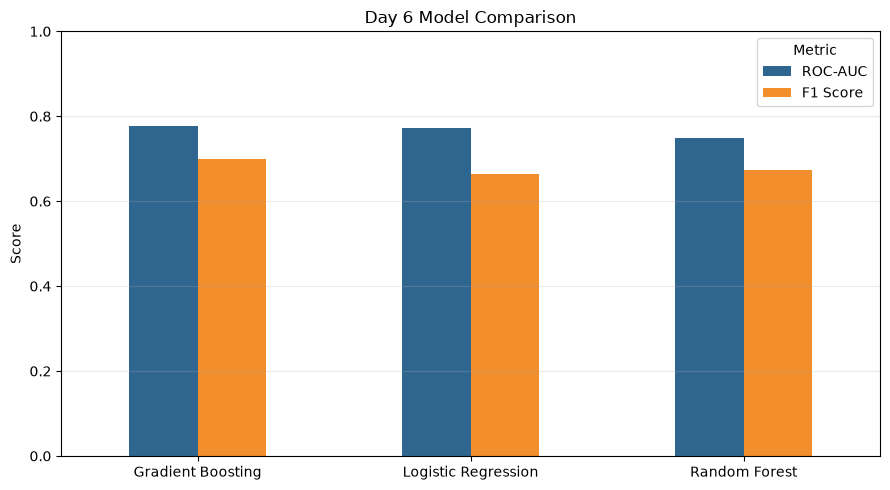

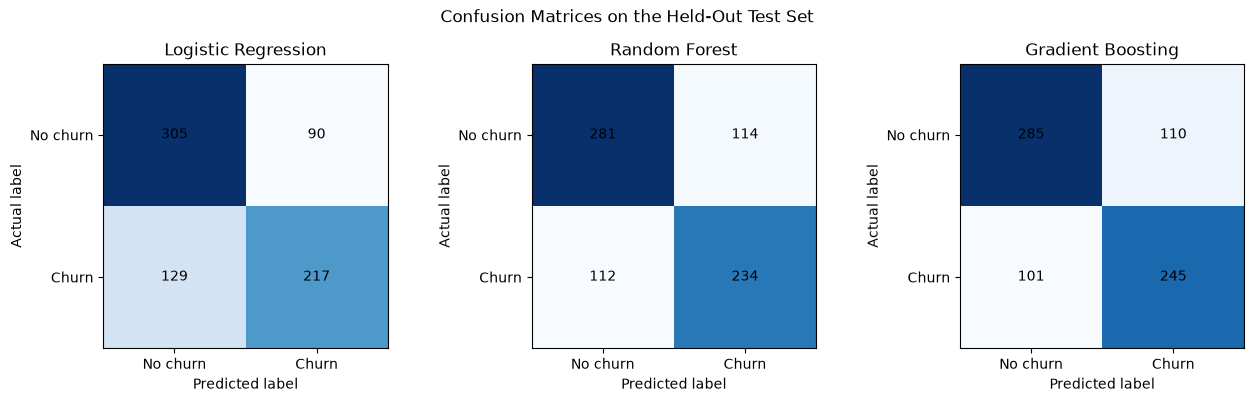

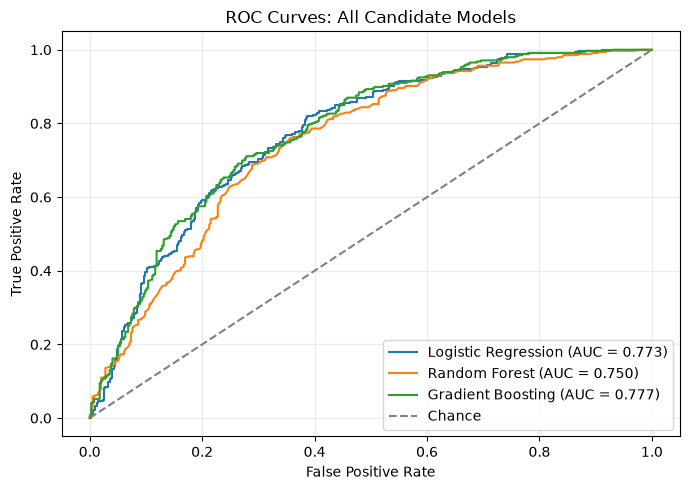

,Feature,Random Forest,Gradient Boosting,Average Tree Importance
0,Recency,0.2470,0.4813,0.3641
1,Monetary,0.2067,0.1859,0.1963
2,Average Purchase Interval,0.1500,0.1417,0.1459
3,Customer Lifespan,0.1586,0.0637,0.1112
4,Median Purchase Interval,0.1458,0.0663,0.1061
5,Frequency,0.0918,0.0610,0.0764


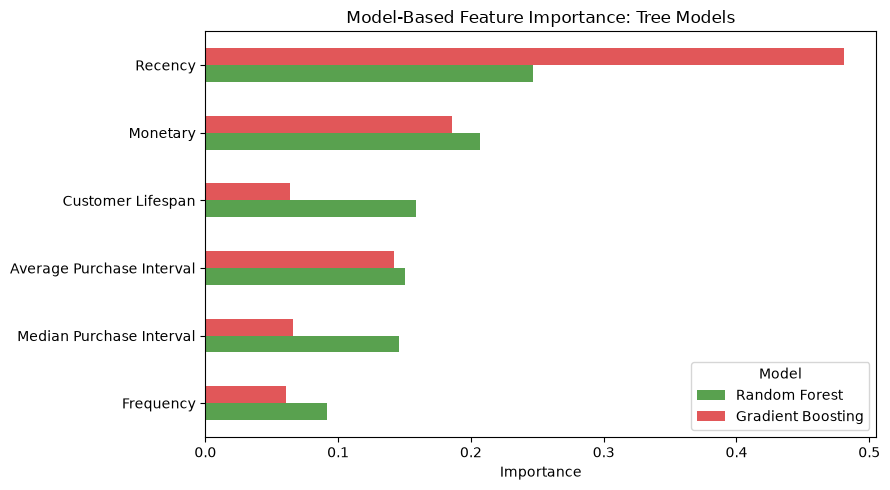

Logistic Regression standardized coefficients (not tree-based importance):


,Feature,Coefficient,Odds Ratio,Direction
0,Average Purchase Interval,0.8286,2.2901,Increased predicted churn risk
1,Recency,0.7017,2.0172,Increased predicted churn risk
2,Monetary,-0.0412,0.9596,Decreased predicted churn risk
3,Customer Lifespan,-0.2650,0.7672,Decreased predicted churn risk
4,Frequency,-0.3835,0.6815,Decreased predicted churn risk
5,Median Purchase Interval,-0.4052,0.6669,Decreased predicted churn risk


Saved: ..\Data\Processed\model_comparison_results.csv
Saved model rows: 3
DAY 6 MODEL COMPARISON REPORT
1. Dataset size: 3705 customers, 6 predictive features
2. Train/test sizes: 2964 / 741
3. Models evaluated: Logistic Regression, Random Forest, Gradient Boosting
4. Performance metrics:
              Model  Train Accuracy  Test Accuracy  Precision  Recall  F1 Score  ROC-AUC  Accuracy Gap Overfitting Assessment
  Gradient Boosting          0.7601         0.7152     0.6901  0.7081    0.6990   0.7769        0.0449            Low concern
Logistic Regression          0.6960         0.7045     0.7068  0.6272    0.6646   0.7731       -0.0084            Low concern
      Random Forest          1.0000         0.6950     0.6724  0.6763    0.6744   0.7497        0.3050           High concern
5. Best ROC-AUC model: Gradient Boosting (0.7769)
6. Best F1 model: Gradient Boosting (0.6990)
7. Evidence regarding overfitting:
   Gradient Boosting: accuracy gap 0.0449 -> Low concern
   Logistic Regress

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
FEATURES = [
    'Frequency',
    'Monetary',
    'Customer Lifespan',
    'Recency',
    'Average Purchase Interval',
    'Median Purchase Interval',
]
TARGET = 'observed_churn'
ID_COLUMN = 'Customer ID'
FORBIDDEN_COLUMNS = {
    ID_COLUMN,
    'returned_in_validation',
    TARGET,
    'First Purchase Date',
    'Last Purchase Date',
}
input_path = Path('../Data/Processed/customer_churn_analysis.csv')
output_path = Path('../Data/Processed/model_comparison_results.csv')

# Load and validate the source dataset before modeling.
assert input_path.exists(), f'Expected input file does not exist: {input_path}'
customers = pd.read_csv(input_path)
required_columns = FEATURES + [ID_COLUMN, TARGET, 'returned_in_validation']
assert customers.shape[0] == 3705, f'Expected 3,705 rows, found {len(customers)}'
assert set(required_columns).issubset(customers.columns)
assert customers[ID_COLUMN].is_unique
assert customers[FEATURES + [TARGET]].notna().all().all()
assert np.isfinite(customers[FEATURES].to_numpy(dtype=float)).all()
assert np.isfinite(customers[TARGET].to_numpy(dtype=float)).all()
assert customers[TARGET].isin([0, 1]).all()
assert customers['returned_in_validation'].isin([0, 1]).all()

X = customers[FEATURES].copy()
y = customers[TARGET].copy()
assert not (set(X.columns) & FORBIDDEN_COLUMNS)
assert X.shape == (3705, 6)
print(f'Input: {input_path}')
print(f'Dataset shape: {customers.shape}')
print(f'Predictor shape: {X.shape}')
print(f'Target distribution: {y.value_counts().sort_index().to_dict()}')
print('Validation checks passed.')

# Match the Day 5 reproducible stratified 80/20 split.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)
assert len(X_train) == 2964
assert len(X_test) == 741
print(f'Train rows: {len(X_train)}')
print(f'Test rows: {len(X_test)}')
print(f'Train churn rate: {y_train.mean():.4f}')
print(f'Test churn rate: {y_test.mean():.4f}')

# Scale only within the Logistic Regression training pipeline.
logistic_regression = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ]
)
random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE,
)
models = {
    'Logistic Regression': logistic_regression,
    'Random Forest': random_forest,
    'Gradient Boosting': gradient_boosting,
}
for model in models.values():
    model.fit(X_train, y_train)
print(f'Fitted models: {", ".join(models)}')

# Use a documented accuracy-gap screening rule for overfitting concern.
def overfitting_assessment(accuracy_gap):
    if accuracy_gap <= 0.05:
        return 'Low concern'
    if accuracy_gap <= 0.15:
        return 'Moderate concern'
    return 'High concern'

results = []
predictions = {}
probabilities = {}
confusion_matrices = {}
for model_name, model in models.items():
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    test_probabilities = model.predict_proba(X_test)[:, 1]
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    accuracy_gap = train_accuracy - test_accuracy
    results.append({
        'Model': model_name,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Precision': precision_score(y_test, test_predictions, zero_division=0),
        'Recall': recall_score(y_test, test_predictions, zero_division=0),
        'F1 Score': f1_score(y_test, test_predictions, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, test_probabilities),
        'Accuracy Gap': accuracy_gap,
        'Overfitting Assessment': overfitting_assessment(accuracy_gap),
    })
    predictions[model_name] = test_predictions
    probabilities[model_name] = test_probabilities
    confusion_matrices[model_name] = confusion_matrix(y_test, test_predictions)

comparison = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
metric_columns = [
    'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1 Score',
    'ROC-AUC', 'Accuracy Gap',
]
display(comparison.style.format({column: '{:.4f}' for column in metric_columns}))

# Plot test ROC-AUC and F1, then one confusion matrix per model.
fig, axis = plt.subplots(figsize=(9, 5))
comparison.set_index('Model')[['ROC-AUC', 'F1 Score']].plot(
    kind='bar', ax=axis, color=['#2f6690', '#f28e2b']
)
axis.set_title('Day 6 Model Comparison')
axis.set_ylabel('Score')
axis.set_ylim(0, 1)
axis.set_xlabel('')
axis.tick_params(axis='x', rotation=0)
axis.grid(axis='y', alpha=0.25)
axis.legend(title='Metric')
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for axis, (model_name, matrix) in zip(axes, confusion_matrices.items()):
    axis.imshow(matrix, cmap='Blues')
    axis.set_title(model_name)
    axis.set_xlabel('Predicted label')
    axis.set_ylabel('Actual label')
    axis.set_xticks([0, 1], ['No churn', 'Churn'])
    axis.set_yticks([0, 1], ['No churn', 'Churn'])
    for row in range(2):
        for column in range(2):
            axis.text(column, row, matrix[row, column], ha='center', va='center')
fig.suptitle('Confusion Matrices on the Held-Out Test Set')
fig.tight_layout()
plt.show()

# Plot all held-out ROC curves together.
fig, axis = plt.subplots(figsize=(7, 5))
for model_name in models:
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities[model_name])
    auc = comparison.loc[comparison['Model'].eq(model_name), 'ROC-AUC'].iloc[0]
    axis.plot(false_positive_rate, true_positive_rate, label=f'{model_name} (AUC = {auc:.3f})')
axis.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Chance')
axis.set_title('ROC Curves: All Candidate Models')
axis.set_xlabel('False Positive Rate')
axis.set_ylabel('True Positive Rate')
axis.legend()
axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()

# Tree importances are model-based and do not establish causation.
tree_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Random Forest': random_forest.feature_importances_,
    'Gradient Boosting': gradient_boosting.feature_importances_,
})
tree_importance['Average Tree Importance'] = tree_importance[['Random Forest', 'Gradient Boosting']].mean(axis=1)
tree_importance = tree_importance.sort_values('Average Tree Importance', ascending=False).reset_index(drop=True)
display(tree_importance.style.format({
    'Random Forest': '{:.4f}',
    'Gradient Boosting': '{:.4f}',
    'Average Tree Importance': '{:.4f}',
}))
importance_plot = tree_importance.set_index('Feature')[['Random Forest', 'Gradient Boosting']].sort_values('Random Forest')
fig, axis = plt.subplots(figsize=(9, 5))
importance_plot.plot(kind='barh', ax=axis, color=['#59a14f', '#e15759'])
axis.set_title('Model-Based Feature Importance: Tree Models')
axis.set_xlabel('Importance')
axis.set_ylabel('')
axis.legend(title='Model')
fig.tight_layout()
plt.show()

# Logistic coefficients are separate from tree-based feature importance.
logistic_classifier = logistic_regression.named_steps['classifier']
coefficient_table = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': logistic_classifier.coef_[0],
})
coefficient_table['Odds Ratio'] = coefficient_table['Coefficient'].map(math.exp)
coefficient_table['Direction'] = coefficient_table['Coefficient'].map(
    lambda value: 'Increased predicted churn risk' if value > 0 else 'Decreased predicted churn risk'
)
coefficient_table = coefficient_table.sort_values('Coefficient', ascending=False).reset_index(drop=True)
print('Logistic Regression standardized coefficients (not tree-based importance):')
display(coefficient_table.style.format({'Coefficient': '{:.4f}', 'Odds Ratio': '{:.4f}'}))

# Save only the derived Day 6 comparison table.
comparison.to_csv(output_path, index=False)
assert output_path.exists()
saved_comparison = pd.read_csv(output_path)
assert list(saved_comparison.columns) == [
    'Model', 'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall',
    'F1 Score', 'ROC-AUC', 'Accuracy Gap', 'Overfitting Assessment',
]
assert len(saved_comparison) == 3
print(f'Saved: {output_path}')
print(f'Saved model rows: {len(saved_comparison)}')

# Generate the requested evidence-based execution report.
best_auc = comparison.iloc[0]
best_f1 = comparison.sort_values('F1 Score', ascending=False).iloc[0]
top_tree_features = tree_importance.head(3)['Feature'].tolist()
logistic_row = comparison.loc[comparison['Model'].eq('Logistic Regression')].iloc[0]
auc_improvement = best_auc['ROC-AUC'] - logistic_row['ROC-AUC']
meaningful_improvement = 'meaningful' if auc_improvement >= 0.02 else 'limited'
print('DAY 6 MODEL COMPARISON REPORT')
print(f'1. Dataset size: {len(customers)} customers, {len(FEATURES)} predictive features')
print(f'2. Train/test sizes: {len(X_train)} / {len(X_test)}')
print(f'3. Models evaluated: {", ".join(models)}')
print('4. Performance metrics:')
print(comparison.to_string(index=False, float_format=lambda value: f'{value:.4f}'))
print(f'5. Best ROC-AUC model: {best_auc["Model"]} ({best_auc["ROC-AUC"]:.4f})')
print(f'6. Best F1 model: {best_f1["Model"]} ({best_f1["F1 Score"]:.4f})')
print('7. Evidence regarding overfitting:')
for _, row in comparison.iterrows():
    print(f'   {row["Model"]}: accuracy gap {row["Accuracy Gap"]:.4f} -> {row["Overfitting Assessment"]}')
print(f'8. Top tree-based features by average importance: {", ".join(top_tree_features)}')
print(f'9. Comparison against Day 5 Logistic Regression baseline: current test ROC-AUC {logistic_row["ROC-AUC"]:.4f}; documented Day 5 ROC-AUC 0.7731')
print(f'   Best-model ROC-AUC improvement over current Logistic Regression: {auc_improvement:+.4f} ({meaningful_improvement} under the 0.02 screening rule)')
print(f'10. Recommended candidate model: {best_auc["Model"]} for further validation, not production deployment.')
print(f'Conclusion: {best_auc["Model"]} performed best on this dataset by ROC-AUC. The improvement is {meaningful_improvement}; overfitting assessment is {best_auc["Overfitting Assessment"]}. Logistic Regression remains preferable when coefficient interpretability and simpler governance outweigh the score difference. Next, validate the candidate with cross-validation, threshold analysis, calibration, and business-cost evaluation before any production decision.')